In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from google.colab import drive
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SKRIPSI/data_clean.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,sentiment
0,0.437841,1.378125,0.253770,-0.153585,2.604510,-1.547431,0.476560,-0.645281,-0.801532,1.024680,...,0.476499,-0.096609,-0.248857,0.088835,2.167795,-0.396196,-0.345256,0.487496,0.699319,0
1,1.087023,1.542678,0.857601,-0.267540,2.677015,-1.693577,0.647663,-0.840934,-0.612903,1.099759,...,0.039993,0.088078,0.131562,0.198266,1.819309,-0.320431,-1.001587,0.707353,0.663776,0
2,0.697670,1.285756,0.412275,0.179421,2.495024,-1.954121,0.785095,-0.980324,0.036652,1.233483,...,0.391330,-0.310352,0.408615,0.210083,1.724566,-0.134582,-0.202154,-0.024626,0.657762,0
3,1.170252,2.274422,0.872046,0.186353,2.598732,-1.639453,0.198257,-1.513268,-0.227135,0.493317,...,0.376421,0.232404,0.046154,0.270994,1.999527,-0.495684,-0.661157,-0.268164,0.414215,0
4,1.022788,2.395046,-0.114040,0.402041,2.419624,-1.434734,-0.332419,-0.714615,-0.348046,1.430623,...,0.041822,0.535952,0.009924,0.588959,2.402876,-0.355139,0.329288,-0.080804,0.309973,0


In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,sentiment
0,0.437841,1.378125,0.253770,-0.153585,2.604510,-1.547431,0.476560,-0.645281,-0.801532,1.024680,...,0.476499,-0.096609,-0.248857,0.088835,2.167795,-0.396196,-0.345256,0.487496,0.699319,0
1,1.087023,1.542678,0.857601,-0.267540,2.677015,-1.693577,0.647663,-0.840934,-0.612903,1.099759,...,0.039993,0.088078,0.131562,0.198266,1.819309,-0.320431,-1.001587,0.707353,0.663776,0
2,0.697670,1.285756,0.412275,0.179421,2.495024,-1.954121,0.785095,-0.980324,0.036652,1.233483,...,0.391330,-0.310352,0.408615,0.210083,1.724566,-0.134582,-0.202154,-0.024626,0.657762,0
3,1.170252,2.274422,0.872046,0.186353,2.598732,-1.639453,0.198257,-1.513268,-0.227135,0.493317,...,0.376421,0.232404,0.046154,0.270994,1.999527,-0.495684,-0.661157,-0.268164,0.414215,0
4,1.022788,2.395046,-0.114040,0.402041,2.419624,-1.434734,-0.332419,-0.714615,-0.348046,1.430623,...,0.041822,0.535952,0.009924,0.588959,2.402876,-0.355139,0.329288,-0.080804,0.309973,0


In [ ]:
X = df.iloc[:, 0:768]
y = df["sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5, stratify=y
)

In [ ]:
print("="*60)
print("  Training Awal — Default Parameter")
print("="*60)

model_default = SVC()
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)

acc_default    = accuracy_score(y_test, y_pred_default)
report_default = classification_report(y_test, y_pred_default, output_dict=True)

print(f"Accuracy: {acc_default}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_default))

# Simpan ke JSON
with open("svm_default.json", "w") as f:
    json.dump({
        "accuracy": acc_default,
        "y_true"  : y_test.tolist(),
        "y_pred"  : y_pred_default.tolist(),
        "report"  : report_default
    }, f)

print("Default results saved!")

  Training Awal — Default Parameter
Accuracy: 0.787801127626858

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       975
           1       0.81      0.75      0.78       976

    accuracy                           0.79      1951
   macro avg       0.79      0.79      0.79      1951
weighted avg       0.79      0.79      0.79      1951

Default results saved!


In [ ]:
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'],  'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01, 0.001]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01, 0.001]},
]

svm_results  = {}
best_score   = 0
best_params  = {}
total_tuning_time = 0  # akumulasi waktu training seluruh kombinasi


In [ ]:
for params in param_grid:
    keys   = [k for k in params if k != 'kernel']
    kernel = params['kernel'][0]

    value_combinations = list(product(*[params[k] for k in keys]))

    for combo in value_combinations:
        current_params = {'kernel': kernel}
        for k, v in zip(keys, combo):
            current_params[k] = v

        print(f"\n{'='*60}")
        print(f"  Parameter: {current_params}")
        print(f"{'='*60}")

        model_svm = SVC(**current_params)

        start = time.time()
        model_svm.fit(X_train, y_train)
        fit_time = time.time() - start
        total_tuning_time += fit_time

        y_pred = model_svm.predict(X_test)

        acc    = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        print(f"Accuracy: {acc}")
        print(f"Waktu training kombinasi ini: {fit_time:.2f} detik")
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred, zero_division=0))

        # Simpan hasil per kombinasi parameter
        param_key = str(current_params)
        svm_results[param_key] = {
            "accuracy"  : acc,
            "fit_time"  : fit_time,
            "y_true"    : y_test.tolist(),
            "y_pred"    : y_pred.tolist(),
            "report"    : report
        }

        if acc > best_score:
            best_score  = acc
            best_params = current_params

        # Simpan ke JSON setiap kombinasi selesai
        with open("svm_tuning.json", "w") as f:
            json.dump(svm_results, f)

print(f"\n{'='*60}")
print(f"PARAMETER TERBAIK: {best_params}")
print(f"ACCURACY TERBAIK : {best_score}")
print(f"TOTAL WAKTU TRAINING (KUMULATIF, {len(svm_results)} kombinasi): {total_tuning_time:.2f} detik")
print(f"{'='*60}")

# Simpan best params
with open("svm_best.json", "w") as f:
    json.dump({
        "best_params"       : best_params,
        "best_score"        : best_score,
        "total_tuning_time" : total_tuning_time
    }, f)

print("Tuning results saved!")



  Parameter: {'kernel': 'linear', 'C': 0.1}
Accuracy: 0.8016401845207586
Waktu training kombinasi ini: 21.68 detik

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       975
           1       0.82      0.77      0.80       976

    accuracy                           0.80      1951
   macro avg       0.80      0.80      0.80      1951
weighted avg       0.80      0.80      0.80      1951


  Parameter: {'kernel': 'linear', 'C': 1}
Accuracy: 0.7903639159405433
Waktu training kombinasi ini: 55.55 detik

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       975
           1       0.80      0.77      0.79       976

    accuracy                           0.79      1951
   macro avg       0.79      0.79      0.79      1951
weighted avg       0.79      0.79      0.79      1951


  Parameter: {'kernel': 'linear', 'C': 10}
Accuracy: 0.7862634546

In [ ]:
rekap = {k: v["accuracy"] for k, v in svm_results.items()}

df_svm = pd.DataFrame.from_dict(rekap, orient='index', columns=['Accuracy'])
df_svm.index.name = 'Parameter'

print("\nREKAP HASIL TUNING SVM")
print("="*60)
print(df_svm.to_string())
print(f"\nDefault Accuracy : {acc_default:.4f}")
print(f"Best Parameter   : {best_params}")
print(f"Best Accuracy    : {best_score:.4f}")


REKAP HASIL TUNING SVM
                                                Accuracy
Parameter                                               
{'kernel': 'linear', 'C': 0.1}                  0.801640
{'kernel': 'linear', 'C': 1}                    0.790364
{'kernel': 'linear', 'C': 10}                   0.786263
{'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale'}   0.759610
{'kernel': 'rbf', 'C': 0.1, 'gamma': 0.1}       0.499744
{'kernel': 'rbf', 'C': 0.1, 'gamma': 0.01}      0.741158
{'kernel': 'rbf', 'C': 0.1, 'gamma': 0.001}     0.760636
{'kernel': 'rbf', 'C': 1, 'gamma': 'scale'}     0.787801
{'kernel': 'rbf', 'C': 1, 'gamma': 0.1}         0.614557
{'kernel': 'rbf', 'C': 1, 'gamma': 0.01}        0.788314
{'kernel': 'rbf', 'C': 1, 'gamma': 0.001}       0.783701
{'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}    0.805741
{'kernel': 'rbf', 'C': 10, 'gamma': 0.1}        0.628396
{'kernel': 'rbf', 'C': 10, 'gamma': 0.01}       0.787289
{'kernel': 'rbf', 'C': 10, 'gamma': 0.001}      0.810354
{'kerne

In [ ]:
# Training SVM (model terbaik hasil tuning)
start = time.time()
svm = SVC(C=10, kernel='rbf', gamma=0.001)
svm.fit(X_train, y_train)
svm_train_time = time.time() - start

# Prediksi SVM
start = time.time()
y_pred = svm.predict(X_test)
svm_infer_time = time.time() - start

print(f"SVM training: {svm_train_time:.2f} detik")
print(f"SVM inferensi: {svm_infer_time:.2f} detik")


SVM training: 17.82 detik
SVM inferensi: 5.20 detik


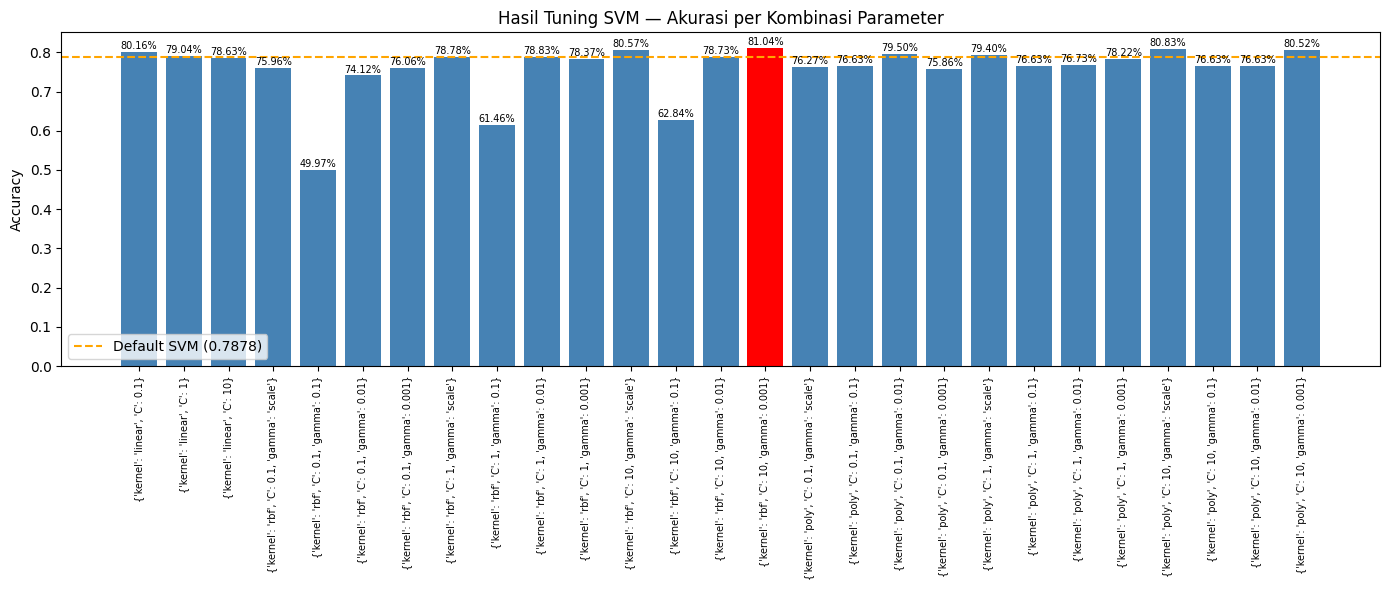

In [ ]:
plt.figure(figsize=(14, 6))

colors = ['red' if v == df_svm['Accuracy'].max() else 'steelblue' for v in df_svm['Accuracy']]

plt.bar(df_svm.index, df_svm['Accuracy'], color=colors)

for idx, val in enumerate(df_svm['Accuracy']):
    plt.text(
        idx,
        val + 0.002,
        f'{val:.2%}',
        ha='center',
        va='bottom',
        fontsize=7,
        rotation=0
    )

plt.axhline(
    y=acc_default,
    color='orange',
    linestyle='--',
    label=f'Default SVM ({acc_default:.4f})'
)

plt.xticks(rotation=90, fontsize=7)
plt.ylabel('Accuracy')
plt.title('Hasil Tuning SVM — Akurasi per Kombinasi Parameter')
plt.legend()
plt.tight_layout()
plt.savefig('svm_tuning_results.png', dpi=150)
plt.show()

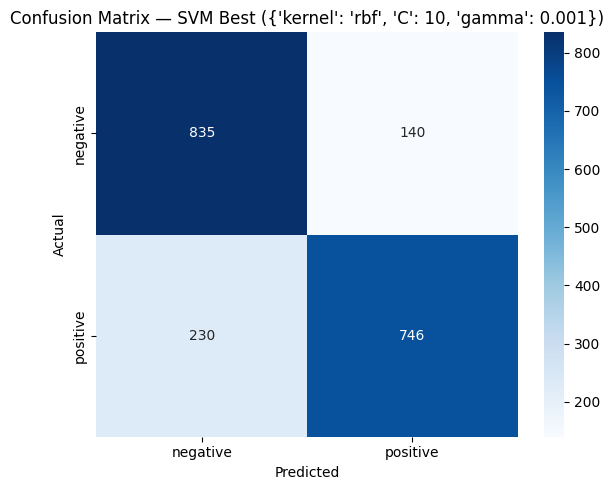

In [ ]:
best_result = svm_results[str(best_params)]
y_true_best = best_result["y_true"]
y_pred_best = best_result["y_pred"]

cm_best = confusion_matrix(y_true_best, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title(f'Confusion Matrix — SVM Best ({best_params})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('svm_confusion_matrix_best.png', dpi=150)
plt.show()